In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv('/Users/nurilasalamat/Documents/ml/sis/tesla_stock_data_2010_2025.csv')
df.columns
df.shape

(3902, 18)

Nominal data: Day_of_week
Ordinal:Date, Quarter, Month
Discrete:Volume, Year
Continuous:Price_Range, Open, High,Low, Close, Daily_Return, Price_Change, Price_Change_Percent, MA_7, MA_30,MA_90, Volatility_7d


Continuous variables can take any real numeric value within a range, while discrete ones represent countable integers. Nominal variables are labels without order, whereas ordinal variables have meaningful ranking

In [5]:
#Descriptive statistics for numeric columns in the DataFrame:

numeric_cols = df.select_dtypes(include=['float64','int64'])

stats = numeric_cols.agg([
    'mean',
    'median',
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'var',
    'std'
])

stats.loc['range'] = numeric_cols.max() - numeric_cols.min()
stats.loc['IQR'] = numeric_cols.quantile(0.75) - numeric_cols.quantile(0.25)

print(stats)

                  Open          High           Low         Close  \
mean         99.192455    101.366984     96.874457     99.172255   
median       19.900000     20.305000     19.540000     19.925000   
<lambda>      1.900000      1.870000      1.820000      1.840000   
var       15722.331013  16413.312705  14984.833554  15702.996384   
std         125.388720    128.114452    122.412555    125.311597   
range       488.800000    497.720000    484.330000    488.830000   
IQR         195.375000    199.715000    190.030000    194.860000   

                Volume  Daily_Return  Price_Range  Price_Change  \
mean      9.674288e+07      0.002107     4.492527     -0.020200   
median    8.331105e+07      0.001000     0.690000      0.000000   
<lambda>  9.922500e+06      0.000000     0.060000     -0.020000   
var       5.731288e+15      0.001326    44.545409     24.737738   
std       7.570527e+07      0.036416     6.674235      4.973705   
range     9.123045e+08      0.455200    61.520000    

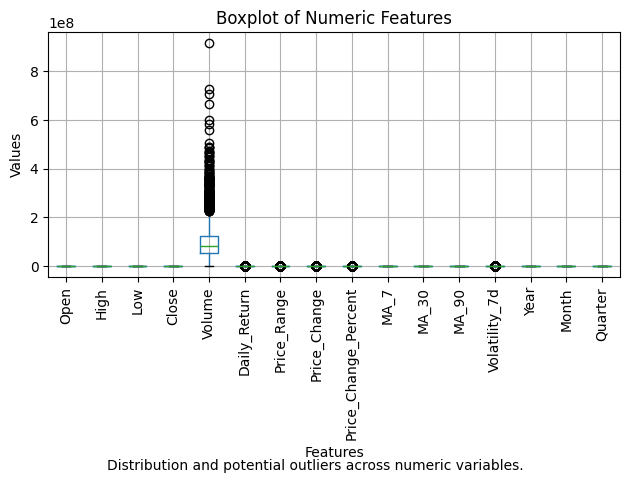

In [6]:
#Boxplot

numeric_cols.boxplot(rot=90)
plt.title("Boxplot of Numeric Features")
plt.xlabel("Features")
plt.ylabel("Values")
plt.figtext(0.5, 0.01, "Distribution and potential outliers across numeric variables.", ha="center")
plt.tight_layout()
plt.show()


Values outside 1.5×IQR from Q1 or Q3 are considered outliers.

In [7]:
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric_cols < (Q1 - 1.5*IQR)) |
            (numeric_cols > (Q3 + 1.5*IQR)))

df[outliers.any(axis=1)]


,Date,Open,High,Low,Close,Volume,Daily_Return,Price_Range,Price_Change,Price_Change_Percent,MA_7,MA_30,MA_90,Volatility_7d,Year,Month,Day_of_Week,Quarter
0,2010-06-29,1.27,1.67,1.17,1.59,281494500,NaN,0.50,0.32,25.20,NaN,NaN,NaN,NaN,2010,6,Tuesday,2
1,2010-06-30,1.72,2.03,1.55,1.59,257806500,0.0000,0.48,-0.13,-7.56,NaN,NaN,NaN,NaN,2010,6,Wednesday,2
2,2010-07-01,1.67,1.73,1.35,1.46,123282000,-0.0818,0.38,-0.21,-12.57,NaN,NaN,NaN,NaN,2010,7,Thursday,3
3,2010-07-02,1.53,1.54,1.25,1.28,77097000,-0.1233,0.29,-0.25,-16.34,NaN,NaN,NaN,NaN,2010,7,Friday,3
4,2010-07-06,1.33,1.33,1.06,1.07,103003500,-0.1641,0.27,-0.26,-19.55,NaN,NaN,NaN,NaN,2010,7,Tuesday,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897,2025-12-24,488.48,490.90,476.80,485.40,41285400,-0.0003,14.10,-3.08,-0.63,483.06,441.53,420.96,0.0274,2025,12,Wednesday,4
3898,2025-12-26,485.23,489.09,473.82,475.19,58780700,-0.0210,15.27,-10.04,-2.07,480.96,443.01,422.58,0.0257,2025,12,Friday,4
3899,2025-12-29,469.00,469.40,459.00,459.64,66263000,-0.0327,10.40,-9.36,-2.00,479.87,444.93,424.09,0.0223,2025,12,Monday,4
3900,2025-12-30,461.09,463.12,453.83,454.43,59238500,-0.0113,9.29,-6.66,-1.44,475.74,446.60,425.58,0.0154,2025,12,Tuesday,4


In [8]:
#Missing data

df_missing = df.copy()

for col in numeric_cols.columns:
    df_missing.loc[df_missing.sample(frac=0.05).index, col] = np.nan



In [9]:
#Constant value imputation method

df_const = df_missing.fillna(0)


In [10]:
#Mean, median, and mode imputation methods
numeric_cols = df_missing.select_dtypes(include=['number'])
df_mean = df_missing.copy()
df_mean[numeric_cols.columns] = numeric_cols.fillna(numeric_cols.mean())

df_median = df_missing.copy()
df_median[numeric_cols.columns] = numeric_cols.fillna(numeric_cols.median())

In [11]:
#Predictive imputation method
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(
    imputer.fit_transform(numeric_cols),
    columns=numeric_cols.columns
)


In [26]:
numeric_missing = df_missing.select_dtypes(include='number')
numeric_mean = df_mean.select_dtypes(include='number')
numeric_knn = df_knn.select_dtypes(include='number')

print("Before imputation:")
df = {"Mean": numeric_missing.mean(), "Std": numeric_missing.std()}
table = pd.DataFrame(df).T
print(table)


Before imputation:
            Open        High         Low       Close        Volume  \
Mean   98.964251  102.080281   96.187319   99.373933  9.649408e+07   
Std   125.175832  128.571079  121.715030  125.232475  7.529992e+07   

      Daily_Return  Price_Range  Price_Change  Price_Change_Percent  \
Mean      0.001988     4.468279     -0.044157              0.030375   
Std       0.036363     6.650309      4.934316              2.987630   

            MA_7       MA_30       MA_90  Volatility_7d         Year  \
Mean   98.967371   98.277007   96.763260       0.031959  2017.714054   
Std   124.824657  123.040013  118.515151       0.017115     4.486680   

         Month   Quarter  
Mean  6.628271  2.543836  
Std   3.419641  1.112606  


In [29]:
print("\nMean imputation:")
df = {"Mean": numeric_mean.mean(), "Std": numeric_mean.std()}
table = pd.DataFrame(df).T
print(table)


Mean imputation:
            Open        High         Low       Close        Volume  \
Mean   98.964251  102.080281   96.187319   99.373933  9.649408e+07   
Std   122.007132  125.316432  118.633936  122.062342  7.339378e+07   

      Daily_Return  Price_Range  Price_Change  Price_Change_Percent  \
Mean      0.001988     4.468279     -0.044157              0.030375   
Std       0.035438     6.481963      4.809409              2.912001   

            MA_7       MA_30       MA_90  Volatility_7d         Year  \
Mean   98.967371   98.277007   96.763260       0.031959  2017.714054   
Std   121.566320  119.455240  114.245711       0.016666     4.373105   

         Month   Quarter  
Mean  6.628271  2.543836  
Std   3.333076  1.084441  


In [30]:

print("\nKNN imputation:")
df = {"Mean": numeric_knn.mean(), "Std": numeric_knn.std()}
table = pd.DataFrame(df).T
print(table)



KNN imputation:
            Open        High         Low       Close        Volume  \
Mean   99.157198  101.343910   96.847940   99.177621  9.744002e+07   
Std   125.260762  128.079415  122.357002  125.289252  7.458290e+07   

      Daily_Return  Price_Range  Price_Change  Price_Change_Percent  \
Mean      0.001814     4.455025      -0.04867              0.026024   
Std       0.035598     6.601689       4.82266              2.924891   

            MA_7      MA_30       MA_90  Volatility_7d         Year     Month  \
Mean   98.789215   97.53642   94.034839       0.031978  2017.716556  6.635879   
Std   124.692809  122.72021  117.571921       0.016801     4.476535  3.369027   

       Quarter  
Mean  2.545566  
Std   1.102047  


Constant value is fast, simple method, however, can bias results heavily.
Mean, median, mode method maintains central tendency, but on the other side reduces variance.
Predictive method makes realistic estimates, on the other side, it is computationally expensive.

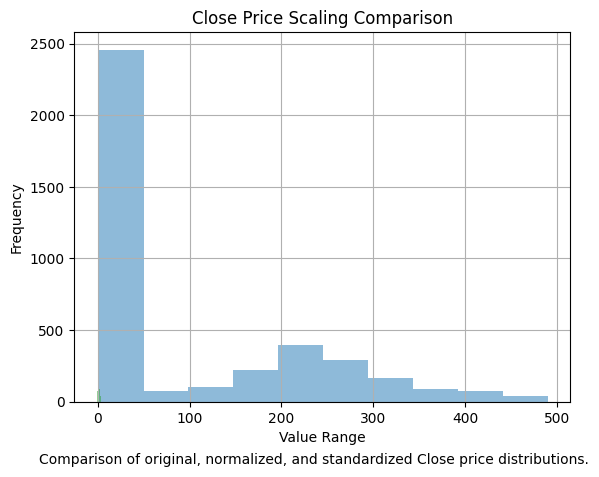

In [15]:
#Normalization and standardization

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

numeric_df = df.select_dtypes(include=[np.number])

feature1 = numeric_df["Close"].fillna(numeric_df["Close"].mean())
feature2 = numeric_df["Volume"].fillna(numeric_df["Volume"].mean())

close_minmax = (feature1 - feature1.min()) / (feature1.max() - feature1.min())
volume_minmax = (feature2 - feature2.min()) / (feature2.max() - feature2.min())

close_z = (feature1 - feature1.mean()) / feature1.std()
volume_z = (feature2 - feature2.mean()) / feature2.std()


plt.figure()
feature1.hist(alpha=0.5)
close_minmax.hist(alpha=0.5)
close_z.hist(alpha=0.5)
plt.title("Close Price Scaling Comparison")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.figtext(0.5, -0.02, "Comparison of original, normalized, and standardized Close price distributions.", ha="center")
plt.show()


Normalization rescales values into the range [0,1], preserving relative relationships but changing magnitude. It is useful when algorithms require bounded input values such as neural networks.
Standardization transforms data to have mean 0 and standard deviation 1. It is preferable when data follow approximately normal distributions or when distance-based models like PCA or regression are used.

In [16]:
#Feature creation
df["Price_Spread"] = df["High"] - df["Low"]

df["Spread_bins_width"] = pd.cut(df["Price_Spread"], bins=4)

df["Spread_bins_freq"] = pd.qcut(df["Price_Spread"], q=4, duplicates="drop")

print(df["Spread_bins_width"].value_counts())
print(df["Spread_bins_freq"].value_counts())
categorical_cols = df.select_dtypes(include=["object"]).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

Spread_bins_width
(-0.0515, 15.39]    3605
(15.39, 30.77]       271
(30.77, 46.15]        22
(46.15, 61.53]         4
Name: count, dtype: int64
Spread_bins_freq
(0.009000000000000001, 0.32]    992
(7.525, 61.53]                  976
(0.69, 7.525]                   971
(0.32, 0.69]                    963
Name: count, dtype: int64


/var/folders/cj/pyg3106x49q_d54nbw4ww5k80000gn/T/ipykernel_1084/322928163.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


Feature creation:
A new feature called Price_Spread was created as the difference between high and low prices, which reflects daily market volatility.
Equal-width binning:
This method divides the data range into intervals of equal size, but some bins may contain many or few observations.
Equal-frequency binning:
This approach ensures each bin contains approximately the same number of observations, improving balance.
One-hot encoding:
Categorical variables were transformed into binary indicators to make them suitable for machine learning algorithms.
Impact on ML models:
Feature engineering can improve predictive power, discretization can reduce noise, and encoding categorical variables allows algorithms to interpret qualitative data numerically.

In [17]:
#Similarity & Dissimilarity measures

v1 = numeric_df["Close"].fillna(numeric_df["Close"].mean()).values[:100]
v2 = numeric_df["Open"].fillna(numeric_df["Open"].mean()).values[:100]

euclidean = np.sqrt(np.sum((v1 - v2)**2))

cosine = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

pearson = np.corrcoef(v1, v2)[0,1]

set1 = set(np.where(v1 > np.mean(v1))[0])
set2 = set(np.where(v2 > np.mean(v2))[0])
jaccard = len(set1 & set2) / len(set1 | set2)

print(euclidean, cosine, pearson, jaccard)

0.7683749084919417 0.9985189094242001 0.9042257867291696 0.625


Euclidean distance measures straight-line distance between two numeric vectors and reflects overall magnitude differences.
Jaccard similarity measures overlap between two sets relative to their union, commonly used for binary or categorical data.
Cosine similarity measures the angle between vectors, focusing on direction rather than magnitude.
Pearson correlation measures linear relationship strength between variables.
Comparison:
Results differ because each metric captures different aspects such as magnitude, direction, overlap, or linear dependence.

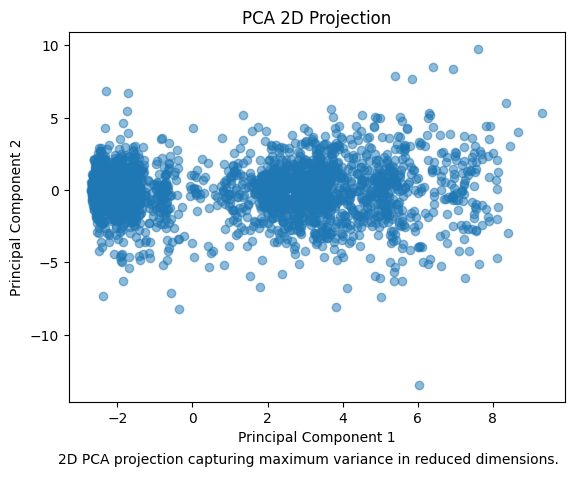

In [18]:
#PCA

data = numeric_df.fillna(numeric_df.mean()).values

data_std = (data - np.mean(data, axis=0)) / np.std(data, axis=0)

cov_matrix = np.cov(data_std, rowvar=False)

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

principal_components = eigenvectors[:, :2]

projected_data = np.dot(data_std, principal_components)


plt.figure()
plt.scatter(projected_data[:,0], projected_data[:,1], alpha=0.5)
plt.title("PCA 2D Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.figtext(0.5, -0.02, "2D PCA projection capturing maximum variance in reduced dimensions.", ha="center")
plt.show()


Standardization: Features were standardized so that each contributes equally to the analysis.
Covariance matrix: This matrix describes how variables vary together.
Eigenvalues and eigenvectors: Eigenvalues indicate variance captured by each principal component, while eigenvectors define their directions.
Projection: Data were projected onto the top two eigenvectors to reduce dimensionality.
PCA visualization: The 2D plot shows the main structure of the dataset while preserving maximum variance.
Comparison with original data: The reduced data simplify visualization while retaining essential relationships among variables.

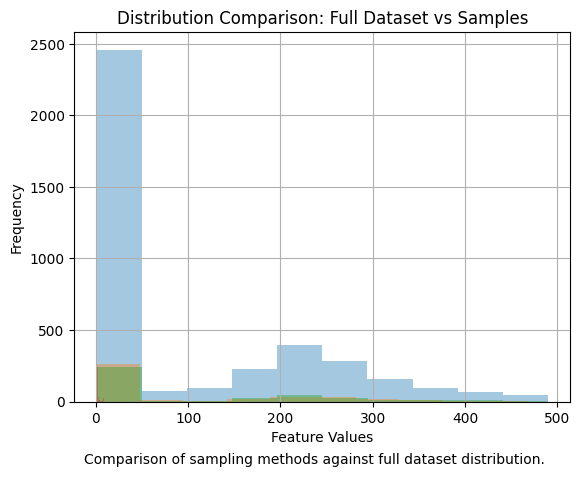

In [19]:
numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df = numeric_df.fillna(numeric_df.mean())

random_sample = numeric_df.sample(frac=0.10, random_state=42)  #simple random sampling

strata_feature = numeric_df.iloc[:, 0] #stratified sampling based on the first numeric feature
bins = pd.qcut(strata_feature, q=4, duplicates="drop")
stratified_sample = numeric_df.groupby(bins, group_keys=False).apply(
    lambda x: x.sample(frac=0.10, random_state=42)
)

cluster_feature = pd.qcut(numeric_df.iloc[:, 0], q=5, duplicates="drop") #cluster sampling 
selected_cluster = cluster_feature.unique()[0]
cluster_sample = numeric_df[cluster_feature == selected_cluster]

def stats(x): #statistics
    return pd.DataFrame({
        "mean": x.mean(),
        "median": x.median(),
        "variance": x.var(),
        "IQR": x.quantile(0.75) - x.quantile(0.25)
    })

full_stats = stats(numeric_df)
random_stats = stats(random_sample)
stratified_stats = stats(stratified_sample)
cluster_stats = stats(cluster_sample)

feature = numeric_df.columns[0]

plt.figure()
numeric_df[feature].hist(alpha=0.4)
random_sample[feature].hist(alpha=0.4)
stratified_sample[feature].hist(alpha=0.4)
cluster_sample[feature].hist(alpha=0.4)
plt.title("Distribution Comparison: Full Dataset vs Samples")
plt.xlabel("Feature Values")
plt.ylabel("Frequency")
plt.figtext(0.5, -0.02, "Comparison of sampling methods against full dataset distribution.", ha="center")
plt.show()

tratified sampling preserved the data distribution most effectively because each subgroup of the dataset was proportionally represented, making its statistical properties closest to those of the full dataset. Simple random sampling also maintained overall trends reasonably well, although smaller subgroups or rare patterns were sometimes underrepresented. Cluster sampling showed larger deviations since selecting a single cluster can introduce bias if that cluster does not fully reflect the entire population. Regarding outlier detection, both random and stratified samples generally retained extreme values present in the original dataset, while cluster sampling occasionally missed them depending on which cluster was selected. This can affect statistical analysis because missing outliers may distort measures such as variance and range. Overall, stratified sampling provided the best balance between representativeness and efficiency for this dataset. Random sampling remains suitable for general exploratory analysis when strict representativeness is not critical. Cluster sampling is most useful when working with very large datasets where computational efficiency is a priority. In real-world projects, the choice of sampling method should depend on dataset structure, available resources, and analysis goals. Selecting an appropriate sampling strategy is essential to ensure reliable conclusions and accurate data-driven decisions.